In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#reading tmdb csv file and storing that to a variable
glimpse_tmdb = pd.read_csv('moviedata.csv')

#calling out first 5 rows (excluding headers) of tmdb database
glimpse_tmdb.head()

,id,title,budget,revenue,genres,runtime,release_date,production_companies,production_countries,cast,director,vote_average,vote_count,popularity,original_language
0,950387,A Minecraft Movie,150000000,10550000,"['Family', 'Comedy', 'Adventure', 'Fantasy']",101,2025-03-31,"['Warner Bros. Pictures', 'Legendary Pictures'...","['Sweden', 'United States of America']","['Jason Momoa', 'Jack Black', 'Sebastian Eugen...",Jared Hess,5.869,126,681.3142,en
1,1229730,Carjackers,0,0,"['Action', 'Adventure']",97,2025-03-27,['Gaumont'],['France'],"['Zoé Marchal', 'Franck Gastambide', 'Bosh', '...",Kamel Guemra,7.130,46,408.9213,fr
2,1125899,Cleaner,0,0,"['Action', 'Thriller']",96,2025-02-19,"['Anton', 'Qwerty Films']",['United Kingdom'],"['Daisy Ridley', 'Clive Owen', 'Taz Skylar', '...",Martin Campbell,6.750,152,355.3781,en
3,1197306,A Working Man,40000000,33392248,"['Action', 'Crime', 'Thriller']",116,2025-03-26,"['Cedar Park Entertainment', 'BlockFilm', 'Pun...","['United Kingdom', 'United States of America']","['Jason Statham', 'David Harbour', 'Michael Pe...",David Ayer,6.900,109,352.8585,en
4,1261050,The Quiet Ones,0,0,"['Action', 'Drama']",110,2024-10-31,"['Zentropa Entertainments', 'Film i Väst', 'Ze...","['Denmark', 'Sweden', 'France']","['Gustav Dyekjær Giese', 'Reda Kateb', 'Amanda...",Frederik Louis Hviid,5.941,17,297.9343,da


In [5]:
glimpse_tmdb.columns

Index(['id', 'title', 'budget', 'revenue', 'genres', 'runtime', 'release_date',
       'production_companies', 'production_countries', 'cast', 'director',
       'vote_average', 'vote_count', 'popularity', 'original_language'],
      dtype='object')

In [7]:
# id, imdb_id, popularity, budget_adj, revenue_adj, homepage, keywords, overview, production_companies, vote_count and vote_average.

In [8]:
rows, col = glimpse_tmdb.shape
#since 'rows' includes count of a header, we need to remove its count.
print('We have {} total entries of movies and {} columns/features of it.'.format(rows-1, col))

We have 9998 total entries of movies and 15 columns/features of it.


In [9]:
#lets give a list of movies that needs to be deleted
del_col = ['id', 'production_countries']

 
#deleting the columns from the database
movie_data = glimpse_tmdb.drop(del_col, axis=1)
#now take a look at this new dataset
movie_data.head()

,title,budget,revenue,genres,runtime,release_date,production_companies,cast,director,vote_average,vote_count,popularity,original_language
0,A Minecraft Movie,150000000,10550000,"['Family', 'Comedy', 'Adventure', 'Fantasy']",101,2025-03-31,"['Warner Bros. Pictures', 'Legendary Pictures'...","['Jason Momoa', 'Jack Black', 'Sebastian Eugen...",Jared Hess,5.869,126,681.3142,en
1,Carjackers,0,0,"['Action', 'Adventure']",97,2025-03-27,['Gaumont'],"['Zoé Marchal', 'Franck Gastambide', 'Bosh', '...",Kamel Guemra,7.130,46,408.9213,fr
2,Cleaner,0,0,"['Action', 'Thriller']",96,2025-02-19,"['Anton', 'Qwerty Films']","['Daisy Ridley', 'Clive Owen', 'Taz Skylar', '...",Martin Campbell,6.750,152,355.3781,en
3,A Working Man,40000000,33392248,"['Action', 'Crime', 'Thriller']",116,2025-03-26,"['Cedar Park Entertainment', 'BlockFilm', 'Pun...","['Jason Statham', 'David Harbour', 'Michael Pe...",David Ayer,6.900,109,352.8585,en
4,The Quiet Ones,0,0,"['Action', 'Drama']",110,2024-10-31,"['Zentropa Entertainments', 'Film i Väst', 'Ze...","['Gustav Dyekjær Giese', 'Reda Kateb', 'Amanda...",Frederik Louis Hviid,5.941,17,297.9343,da


In [10]:
#will drop duplicate rows but will keep the first one
movie_data.drop_duplicates(keep = 'first', inplace = True)

rows, col = movie_data.shape
print('We now have {} total entries of movies and {} columns/features of it.'.format(rows-1, col))

We now have 9766 total entries of movies and 13 columns/features of it.


In [11]:
#giving list of column names that needs to be checked
check_row = ['budget', 'revenue']

#this will replace the value of '0' to NaN of columns given in the list
movie_data[check_row] = movie_data[check_row].replace(0, np.nan)

#now we will drop any row which has NaN values in any of the column of the list (check_row) 
movie_data.dropna(subset = check_row, inplace = True)

rows, col = movie_data.shape
print('After cleaning, we now have only {} entries of movies.'.format(rows-1))

After cleaning, we now have only 4603 entries of movies.


Data Wrangling
Now first lets check if we have any movie with a runtime value of 0. If we have any, we will replace with NaN.

In [12]:
#replacing 0 with NaN of runtime column of the dataframe
movie_data['runtime'] = movie_data['runtime'].replace(0, np.nan)

Now we need to convert the 'release_date' column to date format

In [13]:
#calling the column which need to be formatted in datetime and storing those values in them
movie_data.release_date = pd.to_datetime(movie_data['release_date'])

#showing the dataset
movie_data.head(2)

,title,budget,revenue,genres,runtime,release_date,production_companies,cast,director,vote_average,vote_count,popularity,original_language
0,A Minecraft Movie,150000000.0,10550000.0,"['Family', 'Comedy', 'Adventure', 'Fantasy']",101.0,2025-03-31,"['Warner Bros. Pictures', 'Legendary Pictures'...","['Jason Momoa', 'Jack Black', 'Sebastian Eugen...",Jared Hess,5.869,126,681.3142,en
3,A Working Man,40000000.0,33392248.0,"['Action', 'Crime', 'Thriller']",116.0,2025-03-26,"['Cedar Park Entertainment', 'BlockFilm', 'Pun...","['Jason Statham', 'David Harbour', 'Michael Pe...",David Ayer,6.900,109,352.8585,en


Lets see if all the columns are in the format that we want for our calculations.

In [14]:
movie_data.dtypes

title                           object
budget                         float64
revenue                        float64
genres                          object
runtime                        float64
release_date            datetime64[ns]
production_companies            object
cast                            object
director                        object
vote_average                   float64
vote_count                       int64
popularity                     float64
original_language               object
dtype: object

As we can see we have float values for 'budget' and 'revenue' columns, since we dont need float but in int datatype, lets convert them.

In [15]:
#applymap function changes the columns data type to the type 'argument' we pass
change_coltype = ['budget', 'revenue']

movie_data[change_coltype] = movie_data[change_coltype].applymap(np.int64)
#showing the datatypes of all columns
movie_data.dtypes

C:\Users\Admin\AppData\Local\Temp\ipykernel_19056\4085607653.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  movie_data[change_coltype] = movie_data[change_coltype].applymap(np.int64)


title                           object
budget                           int64
revenue                          int64
genres                          object
runtime                        float64
release_date            datetime64[ns]
production_companies            object
cast                            object
director                        object
vote_average                   float64
vote_count                       int64
popularity                     float64
original_language               object
dtype: object

Since the values in the column 'budget' and 'revenue' shows us in Currency of US (as assumed earlier), lets change the name of these columns for convenience.

In [28]:
movie_data.rename(columns = {'budget' : 'budget_(in_US-Dollars)', 'revenue' : 'revenue_(in_US-Dollars)'}, inplace = True)

Exploratory Data Analysis
Before answering the questions, lets figure out the profits of each movie.

#assigning a new column which will hold the profit values of each movie

#the insert function's first argument is an index number given to locate the column, second argument takes the name of the new column...
#...and last but not least it takes the calculation values to output for specific column

#To calculate profit of each movie, we need to substract the budget from the revenue of each movie
movie_data.insert(2, 'profit_(in_US_Dollars)', movie_data['revenue_(in_US-Dollars)'] - movie_data['budget_(in_US-Dollars)'])

#for just in case situations or for convenience, we change the data type to int
movie_data['profit_(in_US_Dollars)'] = movie_data['profit_(in_US_Dollars)'].apply(np.int64)

#showing the dataset
movie_data.head(2)

In [29]:
movie_data.to_csv("clean_data.csv")

In [18]:
movie_data.shape

(4604, 13)

Which movie earns the most and least profit?

In [19]:
#Let's define a function which calculates lowest and highest values of columns
#taking column name as arguments

def highest_lowest(column_name):
    
    #highest
    #taking the index value of the highest number in profit column
    highest_id = movie_data[column_name].idxmax()
    #calling by index number,storing that row info to a variable
    highest_details = pd.DataFrame(movie_data.loc[highest_id])
    
    #lowest
    #same processing as above
    lowest_id = movie_data[column_name].idxmin()
    lowest_details = pd.DataFrame(movie_data.loc[lowest_id])
    
    #concatenating two dataframes
    two_in_one_data = pd.concat([highest_details, lowest_details], axis = 1)
    
    return two_in_one_data

#calling the function and passing the arg
highest_lowest('profit_(in_US_Dollars)')

KeyError: 'profit_(in_US_Dollars)'

Which movie had the greatest and least runtime?

In [ ]:
#as our calculations seems to be same as previous one for different column, lets call the function by passing desired argument

highest_lowest('runtime')

Which movie had the greatest and least budget?

In [ ]:
#as our calculations seems to be same as previous one for different column, lets call the function by passing desired argument

highest_lowest('budget_(in_US-Dollars)')

Which movie had the greatest and least revenue?

In [ ]:
#again, we will call our function! 
highest_lowest('revenue_(in_US-Dollars)')

What is the average runtime of all movies?

In [20]:
#giving a function which calculates average of a particular column
def average_func(column_name):
    
    return movie_data[column_name].mean()
#calling function to show the mean
average_func('runtime')

np.float64(112.0258583224685)

The average runtime of all movies in this dataset is 109 mins approx. We want to get a deeper look and understanding of runtime of all movies so Let's plot it. **

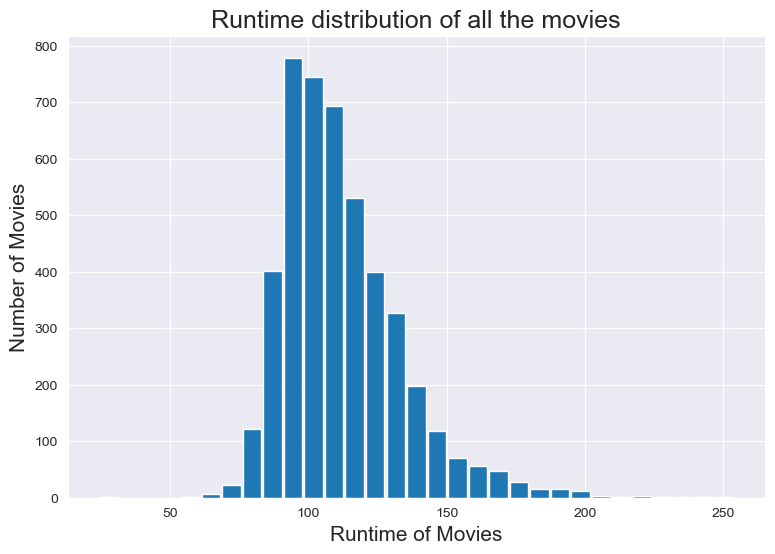

In [21]:
#plotting a histogram of runtime of movies

#gives styles to bg plot
sns.set_style('darkgrid')

#chaging the label size, this will change the size of all plots that we plot from now!
plt.rc('xtick', labelsize = 10)
plt.rc('ytick', labelsize = 10)

#giving the figure size(width, height)
plt.figure(figsize=(9,6), dpi = 100)
#x-axis label name
plt.xlabel('Runtime of Movies', fontsize = 15)
#y-axis label name
plt.ylabel('Number of Movies', fontsize=15)
#title of the graph
plt.title('Runtime distribution of all the movies', fontsize=18)

#giving a histogram plot
plt.hist(movie_data['runtime'], rwidth = 0.9, bins =31)
#displays the plot
plt.show()

Let's dig deep and figure out the outliers of this distribution.

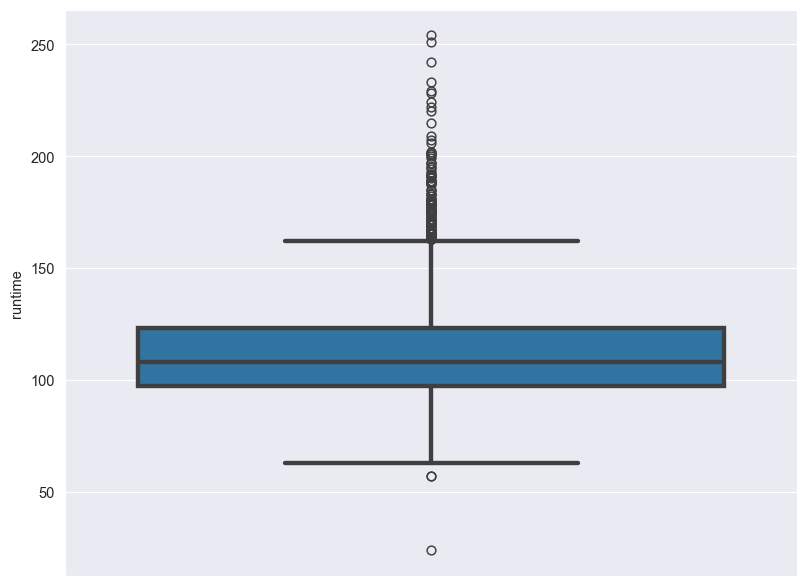

In [22]:
#giving two plots, thr first is the box plot, second is plots of runtime for movies
#giving figure size
plt.figure(figsize=(9,7), dpi = 105)

#using seaborn to plot
#plotting box plot
sns.boxplot(movie_data['runtime'], linewidth = 3)
#showing the plot
plt.show()

In [23]:
#getting specific runtime points at x positions
movie_data['runtime'].describe()

count    4602.000000
mean      112.025858
std        21.770363
min        24.000000
25%        97.000000
50%       108.000000
75%       123.000000
max       254.000000
Name: runtime, dtype: float64

In which year we had the most movies making profits?

In [27]:
# ✅ Extract year first then groupby
movie_data['release_year'] = pd.to_datetime(movie_data['release_date']).dt.year

profits_each_year = movie_data.groupby('release_year')['profit_(in_US_Dollars)'].sum()

plt.figure(figsize=(12, 6), dpi=130)
plt.xlabel('Release Year of Movies', fontsize=12)
plt.ylabel('Total Profits made by Movies', fontsize=12)
plt.title('Total Profits made by all movies per year')
plt.plot(profits_each_year)
plt.show()

KeyError: 'Column not found: profit_(in_US_Dollars)'

In [25]:
#assinging new dataframe which holds values only of movies having profit $50M or more
profit_movie_data = movie_data[movie_data['profit_(in_US_Dollars)'] >= 50000000]

#reindexing new dataframe
profit_movie_data.index = range(len(profit_movie_data))
#will initialize dataframe from 1 instead of 0
profit_movie_data.index = profit_movie_data.index + 1

#showing the dataset
profit_movie_data.head(2)

KeyError: 'profit_(in_US_Dollars)'